# Exploratory Data Anaylsis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv').set_index(['Date'])
inf_data.index = pd.to_datetime(inf_data.index)
inf_data.head()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude
Date,,,,
1958-01-01,6.25000,2.0,NaN,NaN
1958-02-01,6.25000,2.0,NaN,NaN
1958-03-01,5.46875,2.0,NaN,NaN
1958-04-01,5.46875,2.0,NaN,NaN
1958-05-01,6.25000,2.0,NaN,NaN


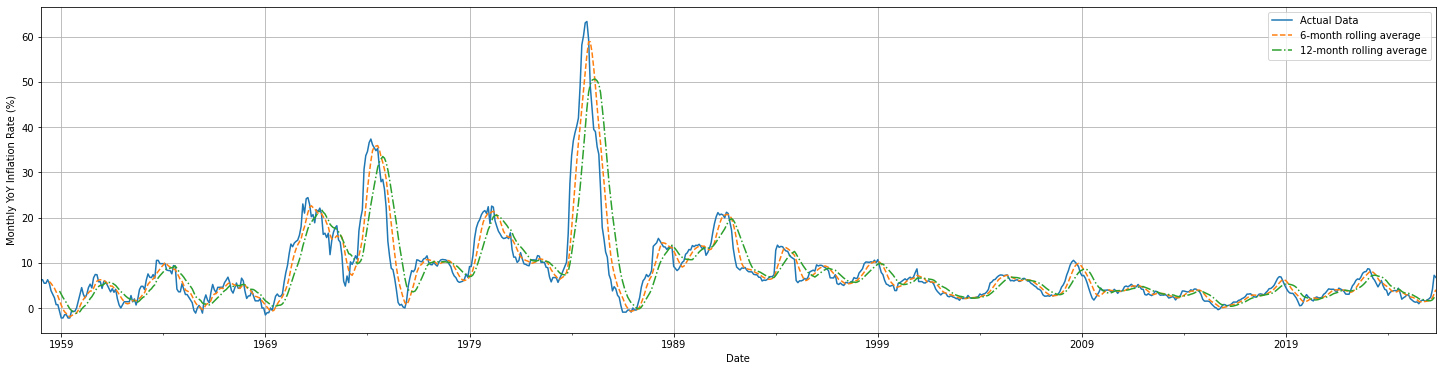

In [3]:
inf_rate = inf_data['InflationRate'].dropna()


plt.figure(figsize=(25, 6))
inf_rate.plot(label = 'Actual Data')
inf_rate.rolling(6).mean().plot(linestyle = '--', label = '6-month rolling average')
inf_rate.rolling(12).mean().plot(linestyle = '-.', label = '12-month rolling average')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.savefig('..//outputs//YoY_Inf_Rate.png', dpi = 250, bbox_inches = 'tight')
plt.show()

In [4]:
print(inf_rate.describe())
print('Skewness: {:.3f}'.format(inf_rate.skew()))
print('Kurtosis: {:.3f}'.format(inf_rate.kurt()))

count    821.000000
mean       7.910747
std        8.411099
min       -2.205882
25%        3.007519
50%        5.797101
75%        9.803922
max       63.333333
Name: InflationRate, dtype: float64
Skewness: 2.964
Kurtosis: 12.246


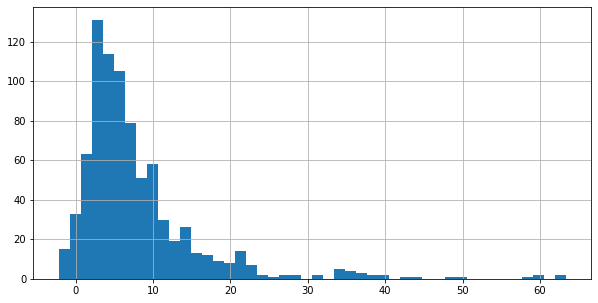

In [5]:
plt.figure(figsize=(10, 5))
inf_rate.hist(bins = 'fd')
plt.savefig('..//outputs//YoY_Inf_Rate_Hist.png', dpi = 250, bbox_inches = 'tight')
plt.show()

In [6]:
adfuller(inf_rate)

(-4.405822176856035,
 0.00028986881500240544,
 21,
 799,
 {'1%': -3.4385608049885876,
  '5%': -2.865164107438179,
  '10%': -2.5686998068142124},
 2559.2892887467983)

The ADF test statistic is `-4.4`. Since the test statistic is less than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. In the Kwiatkowski-Phillips-Schmidt-Shin (KPSS), however, the null hypothesis, $H_0$, is that the series is **stationary**. We reject it when KPSS statistic $>$ critical value.

In [7]:
kpss(inf_rate)

C:\Users\PC\AppData\Local\Temp/ipykernel_15056/3520576699.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(inf_rate)


(0.7668438377492122,
 0.01,
 17,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

The KPSS test statistic is `0.767`. Since the test statistic is greater than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. Taken together, the ADF and KPSS tests provide conflicting evidence regarding stationarity. One possible explanation is the presence of structural breaks in the series. To investigate this possibility, we perform a Zivot-Andrews test. The null hypothesis is that the series contains a unit root with a single structural break.

In [8]:
zivot_andrews(inf_rate.copy())

(-7.043975349159538,
 1e-05,
 {'1%': -5.27644, '5%': -4.81067, '10%': -4.56618},
 21,
 142)

The test statistic is less than all the critical values, so we reject the null hypothesis. This suggests that the data appears stationary around a structural break, suggesting that persistence may arise from regime changes rather than a true unit root. The estimated break occurs at

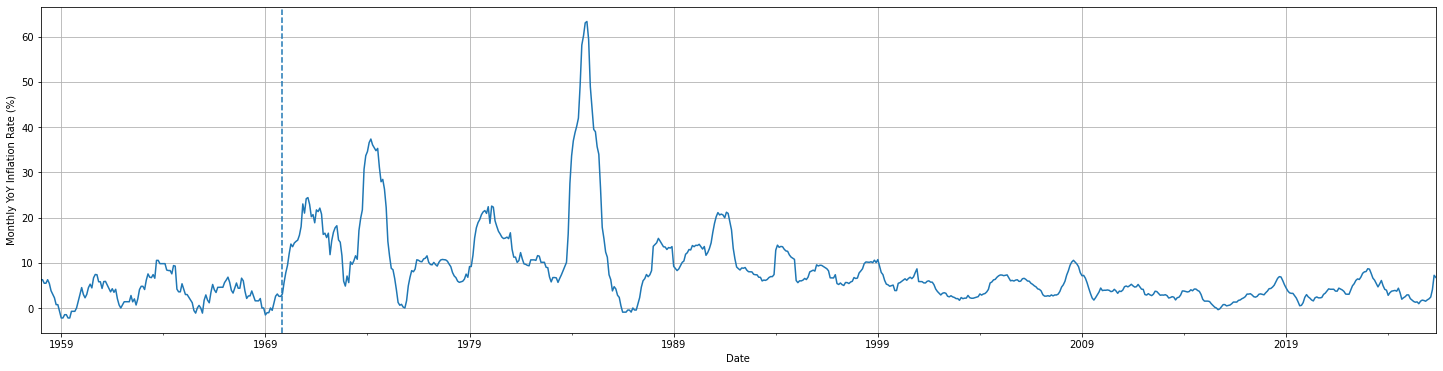

In [9]:
plt.figure(figsize=(25, 6))
inf_rate.plot(label = 'Actual Data')
plt.axvline(pd.Timestamp(inf_rate.index[142]), linestyle = '--')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.grid(True)
plt.show()

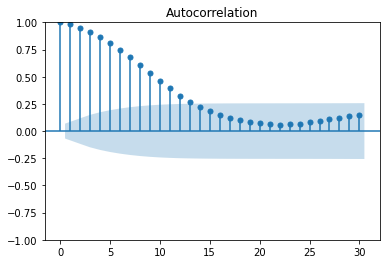

In [10]:
plot_acf(inf_rate)
plt.show()

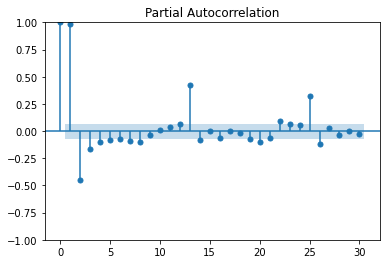

In [11]:
plot_pacf(inf_rate)
plt.show()